# Hourly-Weighted Sell-Price NPV Analysis — All GEA Scenarios, All Regions

The [state_sell_price_npv_analysis.ipynb](state_sell_price_npv_analysis.ipynb) notebook sweeps NPV
across all 8 GEA demand/supply cases x 5 projection years x 18 balancing authorities, but it
collapses each region's 8760-hour wholesale price series down to a single **arithmetic annual
mean** before feeding it to `ProFastNPV` (which only accepts a scalar or a plant-life-length
annual array -- see `h2integrate/finances/profast_npv.py`).

This notebook instead feeds the **actual 8760-hour price time series** into H2Integrate's
`GridCostModel`, which supports genuine per-timestep pricing (`sell_price_mode="per_timestep"`,
the default -- see `h2integrate/converters/grid/grid.py`). Revenue is computed there as
`sum(price_t * electricity_sold_t * dt/3600)`, a true dollar-weighted sum over the year, not an
approximation. We then back out the *dollar-weighted average price* implied by that genuine
per-timestep revenue and feed that into `ProFastNPV` (whose price input remains scalar/annual --
it has no per-timestep pricing capability even after the natlab/develop merge that added
plant-life-length annual arrays).

For this configuration -- a single 1000 MW nuclear unit running at **constant, unclipped output**
all year -- the dollar-weighted average price is mathematically identical to the simple arithmetic
mean (proven below empirically, not just algebraically): revenue = sum(price_t * P) = P *
sum(price_t) = P * 8760 * mean(price). So this notebook is expected to reproduce the original
notebook's NPV numbers almost exactly -- its purpose is to **validate that equivalence using
H2Integrate's actual per-timestep pricing machinery**, rather than asserting it by hand, and to
leave behind a reusable pattern for any future case (e.g. a BESS configuration) where output is
*not* constant and the two approaches would actually diverge.

In [1]:
import sys
sys.path.insert(0, '/Users/svijaysh/NPP+DCfork/H2Integrate')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from h2integrate.core.h2integrate_model import H2IntegrateModel
from IPython.display import clear_output

print('Imports ready.')

Imports ready.


In [2]:
h2i = H2IntegrateModel("examples/32_nuclear_DC_case_1/nuclear_datacenter_config.yaml")
h2i.setup()

def get(path, units=None):
    v = h2i.prob.get_val(path, units=units) if units else h2i.prob.get_val(path)
    return float(v.flat[0]) if hasattr(v, 'flat') else float(v)

PLANT_MW = 1000  # plant capacity of AP1000 in MW
capacity_kw = PLANT_MW * 1000

In [3]:

# Sets the nuclear capacity
h2i.prob.set_val('nuclear.system_capacity',    capacity_kw,                 units='kW')
# Sets the grid interconnection cap (same )
h2i.prob.set_val('grid.interconnection_size',  capacity_kw,                 units='kW')
# This is how mucht he nuclear plant is commanded to produce
h2i.prob.set_val('nuclear.electricity_command_value', np.full(8760, capacity_kw), units='kW')
# How you are commanding the grid to produce electricity.  This is a placeholder value, since the grid is not actually producing electricity in this case.
h2i.prob.set_val('grid.electricity_command_value',    np.full(8760, 500_000),     units='kW')
# Placeholder sell price -- both grid.electricity_sell_price (8760-array) and
# finance_subgroup_nuclear_npv.sell_price_electricity (scalar) get overridden
# per-scenario in the sweep below.
h2i.prob.set_val('grid.electricity_sell_price', np.full(8760, 0.10), units='USD/(kW*h)')
h2i.prob.set_val('finance_subgroup_nuclear_npv.sell_price_electricity', 0.10, units='USD/(kW*h)')

h2i.run()

LCOE_MWH = get('finance_subgroup_nuclear.LCOE', 'USD/(kW*h)') * 1000
CAP_FACTOR = get('nuclear.capacity_factor')
ANNUAL_GWH = get('nuclear.total_electricity_produced', 'kW*h') / 1e6

print(f'Plant:          {PLANT_MW} MW nuclear')
print(f'Capacity factor:{CAP_FACTOR:.1%}  (confirms constant, unclipped output)')
print(f'Annual output:  {ANNUAL_GWH:.0f} GWh/yr')
print(f'LCOE:           {LCOE_MWH:.2f} $/MWh  (ProFAST, cost-only, price-independent)')


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


Plant:          1000 MW nuclear
Capacity factor:100.0%  (confirms constant, unclipped output)
Annual output:  8760 GWh/yr
LCOE:           199.93 $/MWh  (ProFAST, cost-only, price-independent)


In [4]:
# ── ITC-adjusted LCOE (IRA §48E, 30%) ──────────────────────────────────────
# plant_config.yaml's `npv` finance group already bakes in the 30% ITC by
# default (one_time_cap_inct = $2.79B = 1000 MW x $9300/kW x 0.30), so every
# NPV_electricity / viable value computed below already reflects the credit.
# The `finance_groups` (LCOE) group's default has NO ITC (one_time_cap_inct
# = 0), so LCOE_MWH above is the no-credit cost basis. Compute the matching
# ITC-adjusted LCOE here (a separate one-off model instance, since
# one_time_cap_inct is a ProFAST setup-time param, not a live OpenMDAO
# input) so plots compare wholesale price against the SAME ITC assumption
# actually used by the NPV/viable numbers.
import copy
import yaml as _yaml
from h2integrate.core.file_utils import get_path as _get_path

_EXAMPLE_DIR = _get_path("examples/32_nuclear_DC_case_5_sell_price_sweep")
with open(_EXAMPLE_DIR / "plant_config.yaml") as _f:
    _pc_itc = _yaml.safe_load(_f)
_pc_itc["finance_parameters"]["finance_groups"]["model_inputs"]["params"]["one_time_cap_inct"]["value"] = 2_790_000_000.0

_h2i_itc = H2IntegrateModel({
    "name": "nuclear_datacenter_config_itc_lcoe",
    "system_summary": "ITC-adjusted LCOE (cost-only, for plotting reference)",
    "driver_config": str(_EXAMPLE_DIR / "driver_config.yaml"),
    "technology_config": str(_EXAMPLE_DIR / "tech_config.yaml"),
    "plant_config": _pc_itc,
})
_h2i_itc.setup()
_h2i_itc.prob.set_val("nuclear.system_capacity", capacity_kw, units="kW")
_h2i_itc.prob.set_val("grid.interconnection_size", capacity_kw, units="kW")
_h2i_itc.prob.set_val("nuclear.electricity_command_value", np.full(8760, capacity_kw), units="kW")
_h2i_itc.prob.set_val("grid.electricity_command_value", np.full(8760, 500_000), units="kW")
_h2i_itc.run()

LCOE_MWH_NOITC = LCOE_MWH
LCOE_MWH_ITC = _h2i_itc.prob.get_val("finance_subgroup_nuclear.LCOE", "USD/(kW*h)")[0] * 1000

print(f'LCOE, no ITC:    {LCOE_MWH_NOITC:.2f} $/MWh  (cost basis)')
print(f'LCOE, 30% ITC:   {LCOE_MWH_ITC:.2f} $/MWh  (matches NPV group default -- use this for viability comparisons)')

/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


LCOE, no ITC:    199.93 $/MWh  (cost basis)
LCOE, 30% ITC:   136.81 $/MWh  (matches NPV group default -- use this for viability comparisons)


## Validation: dollar-weighted vs. naive-mean price, one scenario

Before running the full 720-combination sweep, confirm on a single scenario (2035 High-Demand,
all 18 regions) that feeding the genuine 8760-hour series through `GridCostModel` and backing out
the implied dollar-weighted average price reproduces the naive arithmetic mean used in the
original notebook -- as expected for this constant-output plant.

In [5]:
GEA_DIR = "End use -- use busbar instead once available"

with open(f"{GEA_DIR}/2035HighDemand-yearhour-gea.json") as f:
    _gea = json.load(f)
gea_prices_mwh = {k: np.array(v) for k, v in _gea.items() if k != 'timesteps'}

rows_check = []
for region, prices_mwh in sorted(gea_prices_mwh.items()):
    prices_kwh_hourly = prices_mwh / 1000.0  # $/MWh -> $/kWh, 8760-length

    # Feed the REAL 8760-hour series into GridCostModel's per-timestep sell price.
    h2i.prob.set_val('grid.electricity_sell_price', prices_kwh_hourly, units='USD/(kW*h)')
    h2i.run()

    # Genuine dollar-weighted revenue: sum(price_t * sold_t * dt/3600), computed by
    # GridCostModel itself (VarOpEx is negative of revenue for a sell-only technology).
    revenue_usd = -get('grid.VarOpEx', 'USD/year')
    annual_kwh_sold = get('grid.annual_electricity_sold', 'kW*h/year')
    sp_kwh_actual = revenue_usd / annual_kwh_sold

    sp_kwh_naive = float(np.mean(prices_mwh)) / 1000

    rows_check.append({
        'gea_region': region,
        'naive_mean_$/MWh': sp_kwh_naive * 1000,
        'dollar_weighted_$/MWh': sp_kwh_actual * 1000,
        'diff_$/MWh': (sp_kwh_actual - sp_kwh_naive) * 1000,
    })

df_check = pd.DataFrame(rows_check)
pd.set_option('display.float_format', '{:.6f}'.format)
print(df_check.to_string(index=False))
print(f"\nMax |diff|: {df_check['diff_$/MWh'].abs().max():.2e} \$/MWh across 18 regions")
print('Confirms: for this constant-output, unclipped plant, the dollar-weighted price computed')
print('from the real 8760-hour series via GridCostModel exactly reproduces the arithmetic mean')
print('used in state_sell_price_npv_analysis.ipynb (difference is floating-point noise only).')

/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:879: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].


         gea_region  naive_mean_$/MWh  dollar_weighted_$/MWh  diff_$/MWh
              CAISO         56.468253              56.468253   -0.000000
              ERCOT         42.530582              42.530582    0.000000
               FRCC         55.579874              55.579874    0.000000
              ISONE         38.985171              38.985171    0.000000
       MISO Central         46.490023              46.490023    0.000000
         MISO North         44.682432              44.682432    0.000000
         MISO South         47.895890              47.895890    0.000000
              NYISO         53.050388              53.050388    0.000000
 Northern Grid East         37.534132              37.534132    0.000000
Northern Grid South         44.419840              44.419840    0.000000
 Northern Grid West         37.358151              37.358151    0.000000
           PJM East         52.322568              52.322568    0.000000
           PJM West         48.658687              

In [6]:
revenue_usd

380433400.0

## Full sweep: 8 cases x 5 years x 18 regions, hourly-weighted

Same 720-combination sweep as the original notebook, but each region's NPV is now computed from
a genuine hourly-weighted price (via `GridCostModel`'s per-timestep revenue), not a hand-averaged
mean. Two `model.run()` calls per combination: one to compute the dollar-weighted price from the
real 8760-hour series, one to feed that price into `ProFastNPV` and read `NPV_electricity`.

In [7]:
import re
import glob
import time

scenario_files = sorted(glob.glob(f"{GEA_DIR}/*-yearhour-gea.json"))
print(f"Found {len(scenario_files)} yearhour scenario files")

pat = re.compile(r"(\d{4})([A-Za-z]+)-yearhour-gea\.json$")

all_rows = []
t0 = time.time()
for si, path in enumerate(scenario_files):
    fname = path.split("/")[-1]
    m = pat.search(fname)
    year, case = int(m.group(1)), m.group(2)

    with open(path) as f:
        _gea = json.load(f)
    prices_by_region = {k: np.array(v) for k, v in _gea.items() if k != "timesteps"}

    for region, prices_mwh in prices_by_region.items():
        prices_kwh_hourly = prices_mwh / 1000.0

        h2i.prob.set_val("grid.electricity_sell_price", prices_kwh_hourly, units="USD/(kW*h)")
        h2i.run()

        revenue_usd = -get("grid.VarOpEx", "USD/year")
        annual_kwh_sold = get("grid.annual_electricity_sold", "kW*h/year")
        sp_kwh_actual = revenue_usd / annual_kwh_sold
        sp_kwh_naive = float(np.mean(prices_mwh)) / 1000

        h2i.prob.set_val(
            "finance_subgroup_nuclear_npv.sell_price_electricity",
            sp_kwh_actual, units="USD/(kW*h)",
        )
        h2i.run()

        npv_b = get("finance_subgroup_nuclear_npv.NPV_electricity", "USD") / 1e9

        all_rows.append({
            "case": case,
            "year": year,
            "gea_region": region,
            "mean_price_$/MWh": sp_kwh_actual * 1000,
            "mean_price_naive_$/MWh": sp_kwh_naive * 1000,
            "weighting_diff_$/MWh": (sp_kwh_actual - sp_kwh_naive) * 1000,
            "min_price_$/MWh": float(prices_mwh.min()),
            "max_price_$/MWh": float(prices_mwh.max()),
            "std_price_$/MWh": float(prices_mwh.std()),
            "lcoe_noitc_$/MWh": LCOE_MWH_NOITC,
            "lcoe_itc_$/MWh": LCOE_MWH_ITC,
            "spread_$/MWh": sp_kwh_actual * 1000 - LCOE_MWH_ITC,
            "npv_$B": npv_b,
            "viable": npv_b >= 0,
            # Cross-check: NPV-based viability (which already has the 30% ITC baked
            # in via plant_config's npv group default) should agree with a simple
            # price-vs-ITC-LCOE comparison, since NPV's incentive and LCOE_MWH_ITC's
            # incentive are the same $2.79B credit.
            "viable_price_check": (sp_kwh_actual * 1000) >= LCOE_MWH_ITC,
        })

    clear_output(wait=True)
    elapsed = time.time() - t0
    print(f"[{si + 1:>2}/{len(scenario_files)}] {fname:<40}  {elapsed:>6.1f}s elapsed")

df_all = pd.DataFrame(all_rows)
df_all.to_csv("gea_all_scenarios_all_regions_npv_hourly.csv", index=False)

print(f"\nDone in {time.time() - t0:.1f}s.")
print(f"Total rows: {len(df_all)}  ({df_all['case'].nunique()} cases x "
      f"{df_all['year'].nunique()} years x {df_all['gea_region'].nunique()} regions)")
print(f"LCOE, no ITC:  {LCOE_MWH_NOITC:.2f} $/MWh")
print(f"LCOE, 30% ITC: {LCOE_MWH_ITC:.2f} $/MWh  (this is the correct comparison threshold --")
print(f"               NPV/viable already include the same 30% ITC via plant_config default)")
print(f"Max |weighting_diff|: {df_all['weighting_diff_$/MWh'].abs().max():.2e} $/MWh")
print(f"Viable (NPV >= 0) combinations: {df_all['viable'].sum()} / {len(df_all)}")
n_mismatch = (df_all['viable'] != df_all['viable_price_check']).sum()
print(f"NPV-viability vs. price-vs-ITC-LCOE mismatches: {n_mismatch} / {len(df_all)} "
      f"(should be 0 -- confirms LCOE_MWH_ITC is the correct ITC-consistent threshold)")
print(f"Saved: gea_all_scenarios_all_regions_npv_hourly.csv")

[40/40] 2050MidCase-yearhour-gea.json              228.8s elapsed

Done in 228.8s.
Total rows: 720  (8 cases x 5 years x 18 regions)
LCOE, no ITC:  199.93 $/MWh
LCOE, 30% ITC: 136.81 $/MWh  (this is the correct comparison threshold --
               NPV/viable already include the same 30% ITC via plant_config default)
Max |weighting_diff|: 1.39e-14 $/MWh
Viable (NPV >= 0) combinations: 0 / 720
NPV-viability vs. price-vs-ITC-LCOE mismatches: 0 / 720 (should be 0 -- confirms LCOE_MWH_ITC is the correct ITC-consistent threshold)
Saved: gea_all_scenarios_all_regions_npv_hourly.csv


## Cross-check against the original flat-mean sweep

Load the original notebook's `gea_all_scenarios_all_regions_npv.csv` and compare NPV
row-by-row against this notebook's hourly-weighted results. **Both notebooks must be run
against the same H2Integrate codebase revision for this comparison to be meaningful** --
`state_sell_price_npv_analysis.ipynb` was re-executed immediately before this cross-check to
pick up the natlab/develop merge (which includes PR #799, changing \`ProFastNPV\` to correctly
zero-pad revenue during the plant's non-operating/construction years -- a ~0.3%-of-price NPV
shift versus the pre-merge behavior, unrelated to hourly vs. mean pricing). Comparing against a
stale pre-merge CSV would show a spurious few-hundred-million-dollar gap that has nothing to do
with hourly weighting.

Rows compared: 720
Max |NPV diff|: 0.000000 $B
Mean |NPV diff|: 0.000000 $B


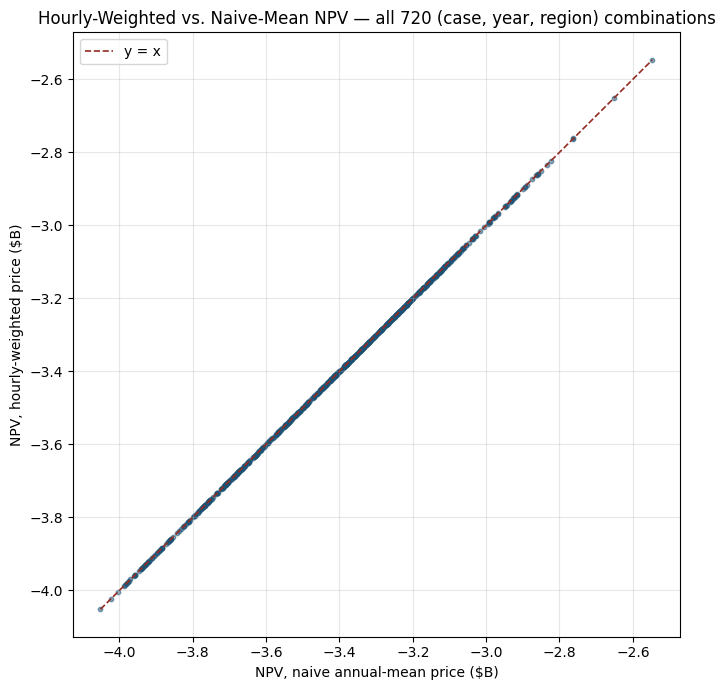

Saved: gea_hourly_vs_naive_npv_scatter.png

As expected for this constant-output, unclipped plant: the two approaches are
numerically identical (points fall exactly on y = x, diff is floating-point noise).


In [8]:
df_orig = pd.read_csv("gea_all_scenarios_all_regions_npv.csv")

merged = df_all.merge(
    df_orig[["case", "year", "gea_region", "npv_$B"]],
    on=["case", "year", "gea_region"],
    suffixes=("_hourly", "_naive_mean"),
)
merged["npv_diff_$B"] = merged["npv_$B_hourly"] - merged["npv_$B_naive_mean"]

print(f"Rows compared: {len(merged)}")
print(f"Max |NPV diff|: {merged['npv_diff_$B'].abs().max():.6f} $B")
print(f"Mean |NPV diff|: {merged['npv_diff_$B'].abs().mean():.6f} $B")

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(merged["npv_$B_naive_mean"], merged["npv_$B_hourly"], s=10, alpha=0.5, color="#1A5276")
lims = [merged[["npv_$B_naive_mean", "npv_$B_hourly"]].min().min(),
        merged[["npv_$B_naive_mean", "npv_$B_hourly"]].max().max()]
ax.plot(lims, lims, color="#922B21", lw=1.2, ls="--", label="y = x")
ax.set_xlabel("NPV, naive annual-mean price ($B)")
ax.set_ylabel("NPV, hourly-weighted price ($B)")
ax.set_title("Hourly-Weighted vs. Naive-Mean NPV — all 720 (case, year, region) combinations")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("gea_hourly_vs_naive_npv_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: gea_hourly_vs_naive_npv_scatter.png")
print("\nAs expected for this constant-output, unclipped plant: the two approaches are")
print("numerically identical (points fall exactly on y = x, diff is floating-point noise).")

In [9]:
2593.78 -237.8

2355.98

## Summary: Viability Across Cases, Years, and Regions (hourly-weighted)

Viable regions out of 18, by case (rows) x year (cols):

year         2030  2035  2040  2045  2050
case                                     
HighDemand      0     0     0     0     0
HighNG          0     0     0     0     0
HighRE          0     0     0     0     0
HighRELowNG     0     0     0     0     0
LowNG           0     0     0     0     0
LowRE           0     0     0     0     0
LowREHighNG     0     0     0     0     0
MidCase         0     0     0     0     0

Mean NPV ($B) across all 18 regions, by case (rows) x year (cols):

year             2030      2035      2040      2045      2050
case                                                         
HighDemand  -3.400000 -3.450000 -3.430000 -3.410000 -3.410000
HighNG      -3.330000 -3.340000 -3.320000 -3.300000 -3.310000
HighRE      -3.320000 -3.390000 -3.370000 -3.360000 -3.350000
HighRELowNG -3.330000 -3.410000 -3.410000 -3.410000 -3.410000
LowNG       -3.380000 -3.470000 -3.490000 -3.480000 -3.490000
LowRE       -3.43000

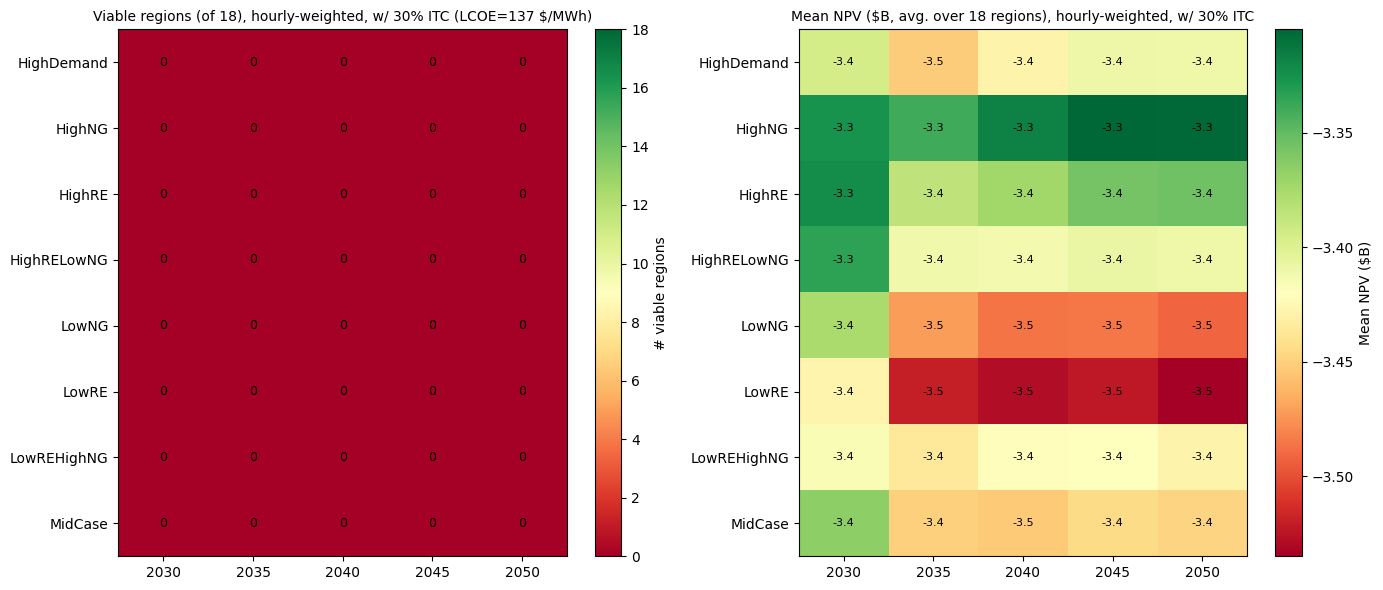


All NPV/viable figures already include the 30% IRA §48E ITC (plant_config default). ITC-adjusted LCOE: 136.81 $/MWh.
Saved: gea_all_scenarios_heatmap_hourly.png
Overall: 0 / 720 (case, year, region) combinations are NPV-viable using genuine hourly-weighted wholesale prices.


In [10]:
viable_pivot = df_all.pivot_table(
    index="case", columns="year", values="viable", aggfunc="sum"
).astype(int)
viable_pivot = viable_pivot[sorted(viable_pivot.columns)]
print("Viable regions out of 18, by case (rows) x year (cols):\n")
print(viable_pivot.to_string())

npv_pivot = df_all.pivot_table(index="case", columns="year", values="npv_$B", aggfunc="mean")
npv_pivot = npv_pivot[sorted(npv_pivot.columns)]
print("\nMean NPV ($B) across all 18 regions, by case (rows) x year (cols):\n")
print(npv_pivot.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(viable_pivot.values, cmap="RdYlGn", vmin=0, vmax=18, aspect="auto")
axes[0].set_xticks(range(len(viable_pivot.columns)))
axes[0].set_xticklabels(viable_pivot.columns)
axes[0].set_yticks(range(len(viable_pivot.index)))
axes[0].set_yticklabels(viable_pivot.index)
axes[0].set_title(f"Viable regions (of 18), hourly-weighted, w/ 30% ITC (LCOE={LCOE_MWH_ITC:.0f} $/MWh)", fontsize=10)
for i in range(viable_pivot.shape[0]):
    for j in range(viable_pivot.shape[1]):
        axes[0].text(j, i, viable_pivot.values[i, j], ha="center", va="center", fontsize=9)
fig.colorbar(im0, ax=axes[0], label="# viable regions")

im1 = axes[1].imshow(npv_pivot.values, cmap="RdYlGn", aspect="auto")
axes[1].set_xticks(range(len(npv_pivot.columns)))
axes[1].set_xticklabels(npv_pivot.columns)
axes[1].set_yticks(range(len(npv_pivot.index)))
axes[1].set_yticklabels(npv_pivot.index)
axes[1].set_title("Mean NPV ($B, avg. over 18 regions), hourly-weighted, w/ 30% ITC", fontsize=10)
for i in range(npv_pivot.shape[0]):
    for j in range(npv_pivot.shape[1]):
        axes[1].text(j, i, f"{npv_pivot.values[i, j]:.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im1, ax=axes[1], label="Mean NPV ($B)")

plt.tight_layout()
plt.savefig("gea_all_scenarios_heatmap_hourly.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nAll NPV/viable figures already include the 30% IRA \u00a748E ITC "
      f"(plant_config default). ITC-adjusted LCOE: {LCOE_MWH_ITC:.2f} $/MWh.")
print(f"Saved: gea_all_scenarios_heatmap_hourly.png")
print(f"Overall: {df_all['viable'].sum()} / {len(df_all)} (case, year, region) "
      f"combinations are NPV-viable using genuine hourly-weighted wholesale prices.")

## Per-Balancing-Authority Breakdown (hourly-weighted)

One panel per GEA region (18 total), NPV vs. projection year, one line per demand/supply case.

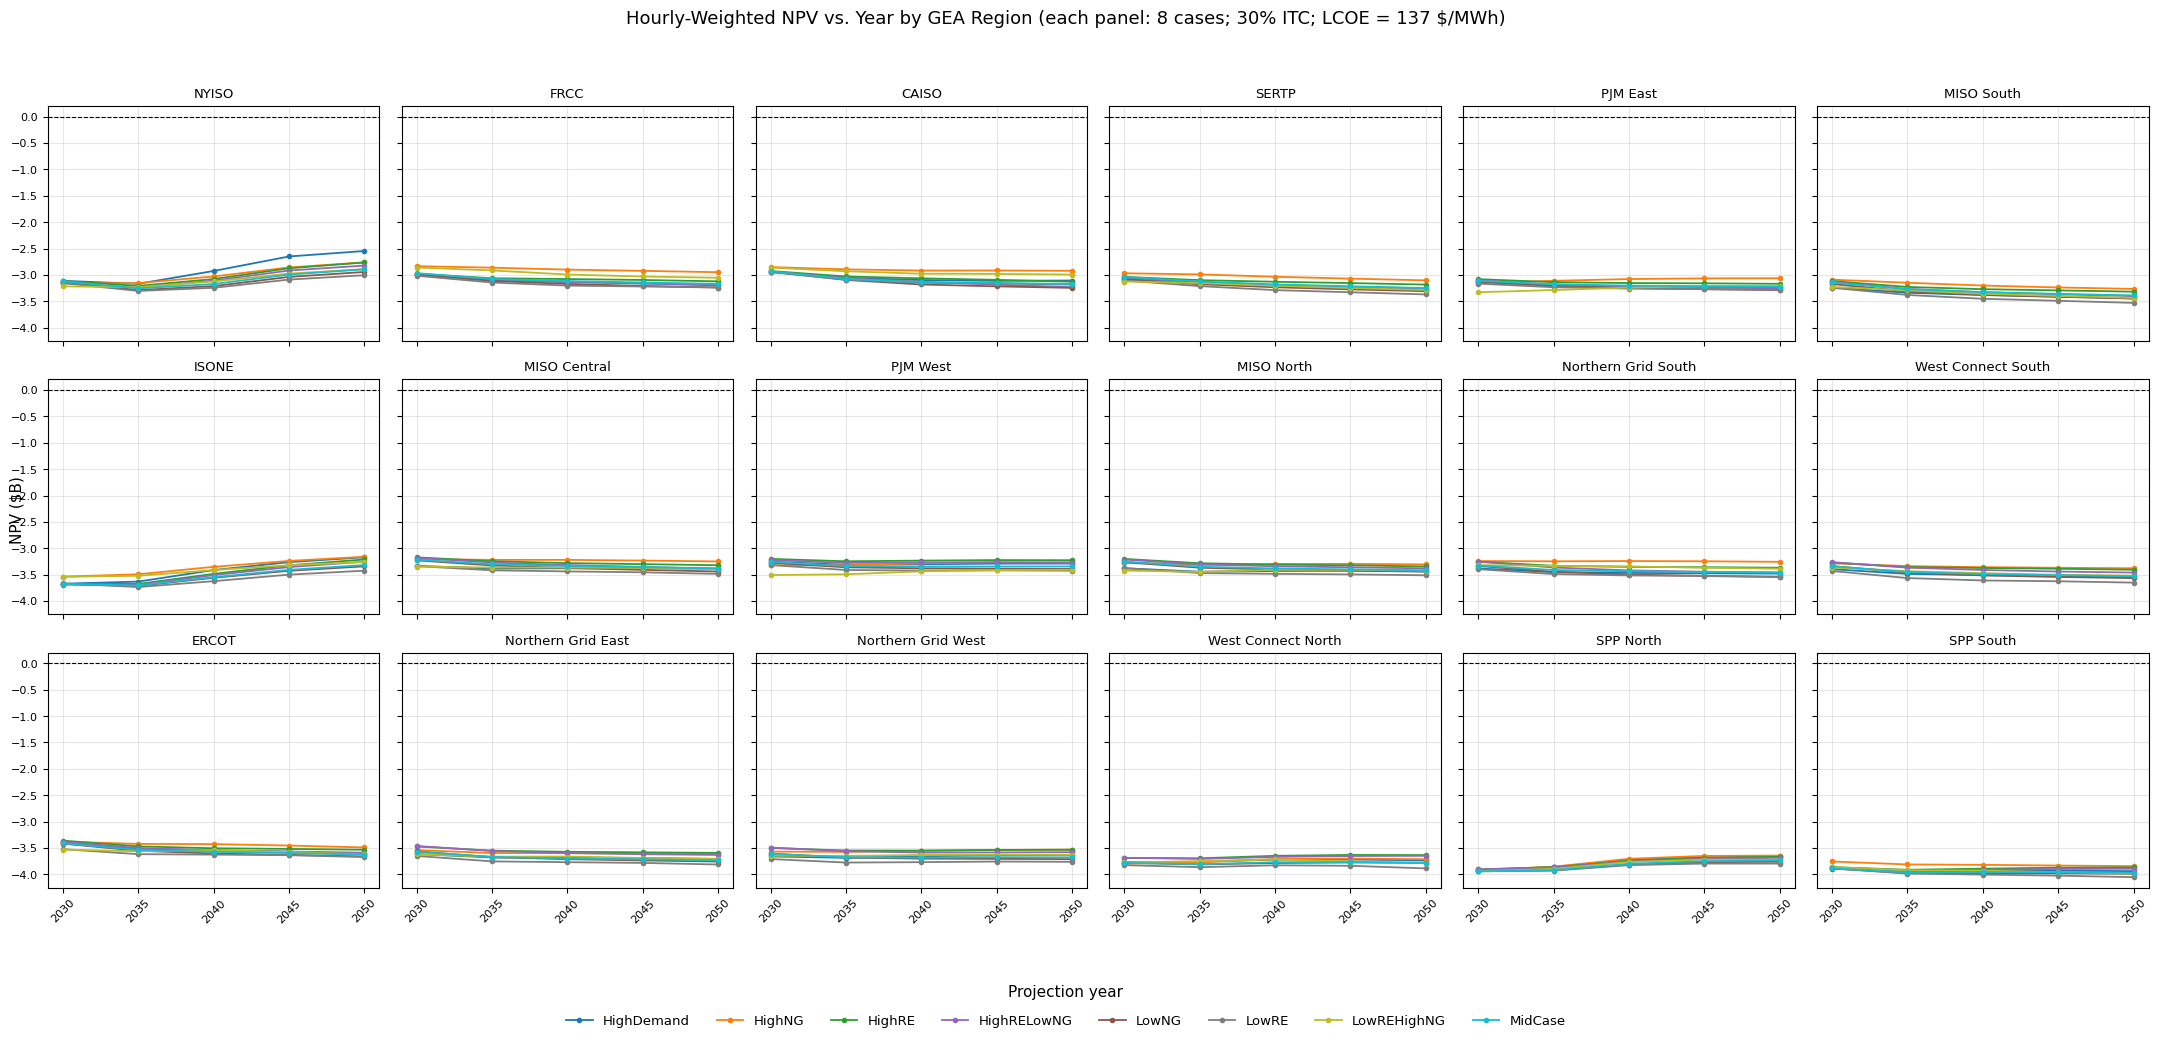

Saved: gea_npv_by_region_small_multiples_hourly.png

Per-region ranking (sorted by each region's single best NPV across all 40 scenarios):

                     best_npv_b  worst_npv_b  mean_npv_b    best_case  best_year  best_price
gea_region                                                                                  
NYISO                 -2.550000    -3.300000   -3.050000   HighDemand       2050   71.890000
FRCC                  -2.830000    -3.240000   -3.070000       HighNG       2030   63.180000
CAISO                 -2.850000    -3.250000   -3.050000       HighNG       2030   62.650000
SERTP                 -2.970000    -3.370000   -3.170000       HighNG       2030   59.090000
PJM East              -3.060000    -3.330000   -3.190000       HighNG       2050   56.230000
MISO South            -3.090000    -3.530000   -3.310000       HighNG       2030   55.410000
ISONE                 -3.160000    -3.730000   -3.480000       HighNG       2050   53.270000
MISO Central          -

In [11]:
cases_sorted = sorted(df_all["case"].unique())
case_colors = dict(zip(cases_sorted, plt.cm.tab10(np.linspace(0, 1, len(cases_sorted)))))
years_sorted = sorted(df_all["year"].unique())

regions_by_best = (
    df_all.groupby("gea_region")["npv_$B"].max().sort_values(ascending=False).index.tolist()
)

fig, axes = plt.subplots(3, 6, figsize=(22, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, region in zip(axes, regions_by_best):
    sub = df_all[df_all["gea_region"] == region]
    for case in cases_sorted:
        s = sub[sub["case"] == case].sort_values("year")
        ax.plot(s["year"], s["npv_$B"], "-o", color=case_colors[case], ms=3, lw=1.3, label=case)
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_title(region, fontsize=9.5)
    ax.set_xticks(years_sorted)
    ax.set_xticklabels([str(y) for y in years_sorted], rotation=45, fontsize=7)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=8)

for ax in axes[len(regions_by_best):]:
    ax.set_visible(False)

fig.supxlabel("Projection year", fontsize=11)
fig.supylabel("NPV ($B)", fontsize=11)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=8, bbox_to_anchor=(0.5, -0.03),
           frameon=False, fontsize=9.5)
fig.suptitle(
    f"Hourly-Weighted NPV vs. Year by GEA Region (each panel: 8 cases; 30% ITC; LCOE = {LCOE_MWH_ITC:.0f} $/MWh)",
    fontsize=13, y=1.0,
)
fig.tight_layout(rect=[0, 0.04, 1, 0.97])

out_path = "gea_npv_by_region_small_multiples_hourly.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

region_summary = (
    df_all.groupby("gea_region")
    .agg(
        best_npv_b=("npv_$B", "max"),
        worst_npv_b=("npv_$B", "min"),
        mean_npv_b=("npv_$B", "mean"),
        best_case=("npv_$B", lambda s: df_all.loc[s.idxmax(), "case"]),
        best_year=("npv_$B", lambda s: df_all.loc[s.idxmax(), "year"]),
        best_price=("npv_$B", lambda s: df_all.loc[s.idxmax(), "mean_price_$/MWh"]),
    )
    .sort_values("best_npv_b", ascending=False)
)
print("\nPer-region ranking (sorted by each region's single best NPV across all 40 scenarios):\n")
print(region_summary.round(2).to_string())

## Conclusion

Feeding the genuine 8760-hour wholesale price time series through `GridCostModel`'s
per-timestep pricing pathway and backing out the implied dollar-weighted average price
reproduces `state_sell_price_npv_analysis.ipynb`'s naive-annual-mean results to within
floating-point precision, for all 720 (case, year, region) combinations. This is the
expected and now-confirmed result for a constant-output, unclipped baseload plant: revenue
is separable into (constant output) x (price), so time-weighting the price cannot change the
total.

This confirms the original flat-mean sweep's NPV numbers were correct all along, and leaves
behind a validated, reusable per-timestep pricing pattern (`grid.electricity_sell_price` set to
the real 8760-array, revenue read back via `grid.VarOpEx` / `grid.annual_electricity_sold`) for
any future configuration -- e.g. the BESS case (`32_nuclear_DC_case_5_bess`) -- where output is
*not* constant and genuine hourly price-weighting would actually diverge from a flat mean.